# Bayesian Optimization evaluation

Loads one TraceWin Bayesian Optimization report (`results.json`, produced by
`scripts/bayesian_opt.py`) and renders its configuration, convergence, parameter-shift, and
**wall-clock cost** inline. The convergence and delta plots call `save_convergence_plot()` /
`save_delta_plot()` from `scripts/bayesian_opt.py` directly -- the same functions the CLI uses to
write PNGs to disk -- nothing here reimplements that plotting logic. The timing section is new: it is
not part of the CLI output, and exists specifically to answer "how long does it take to reach this
score?", not just "how many TraceWin evaluations does it take?".

Every Bayesian evaluation in the report carries a `timestamp`; warm-start points (reused rows from an
existing offline dataset, no fresh TraceWin call) do not, so they cost zero additional wall-clock time
and are excluded from the timing analysis.

This notebook is read-only: it loads an existing `results.json` and renders it in memory, it does not
run any new optimization or TraceWin simulation.

**Related notebooks:**
- [`env/tracewin_env/tracewin/visualize_distributions_python_run.ipynb`](../../env/tracewin_env/tracewin/visualize_distributions_python_run.ipynb)
  -- compares a single hardcoded parameter set against the default, without running Bayesian
  Optimization.

In [1]:
from datetime import datetime
from pathlib import Path
import json
import sys
import tempfile

import numpy as np
from IPython.display import Image, Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.paths import DEFAULT_BAYESIAN_RESULTS_DIR
from beam_optimization.scripts.bayesian_opt import save_convergence_plot, save_delta_plot


def fmt(value):
    if value is None:
        return 'n/a'
    return f'{float(value):.6g}'


def fmt_duration(seconds):
    if seconds is None:
        return 'n/a'
    seconds = float(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    if hours >= 1:
        return f'{int(hours)}h {int(minutes)}m {int(secs)}s'
    if minutes >= 1:
        return f'{int(minutes)}m {int(secs)}s'
    return f'{secs:.1f}s'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

## Modify here

Point `RESULTS_DIR` at any experiment folder under `results/bayesian_opt/` that holds a
`results.json` (produced by `scripts/bayesian_opt.py` / `commands/bayesian_opt.sh`).

In [2]:
# <-- MODIFY HERE: point at any beamsian_opt experiment folder containing results.json.
RESULTS_DIR = DEFAULT_BAYESIAN_RESULTS_DIR / 'warm_start_workspace1_5x300'
# e.g. RESULTS_DIR = DEFAULT_BAYESIAN_RESULTS_DIR / 'cold_start_workspace1_5x300'

## 1. Report and configuration

Loads `results.json` and prints the settings that determine both convergence speed and wall-clock
cost per evaluation: how many parallel restarts (`n_runs`) and TraceWin calls per restart (`n_calls`),
how the search space was scaled (`bounds_scale`), how many warm-start points were reused for free
(`warm_best` + `warm_diverse`), and the TraceWin execution settings (`tracewin_threads`, `timeout`,
`retries`) that directly set the per-evaluation time budget.

In [3]:
RESULTS_JSON = RESULTS_DIR / 'results.json'
if not RESULTS_JSON.exists():
    raise FileNotFoundError(f'No results.json found in {RESULTS_DIR}')

report = json.loads(RESULTS_JSON.read_text(encoding='utf-8'))
config = report['config']
runs = report['runs']

config_rows = [
    ['Dataset', config.get('dataset')],
    ['TraceWin project', config.get('project')],
    ['TraceWin evaluations per run (n_calls)', config.get('n_calls')],
    ['Independent runs (n_runs)', config.get('n_runs')],
    ['Warm start: best / diverse', f"{config.get('warm_best')} / {config.get('warm_diverse')}"],
    ['Search-space bounds scale', config.get('bounds_scale')],
    ['Optimizer base seed', config.get('seed')],
    ['TraceWin threads per call', config.get('tracewin_threads')],
    ['TraceWin timeout (s)', config.get('timeout')],
    ['TraceWin retries', config.get('retries')],
    ['TraceWin particles', config.get('tracewin_particles')],
    ['Status', report.get('status')],
    ['Created (UTC)', report.get('created_at')],
    ['Last updated (UTC)', report.get('updated_at')],
]
display(Markdown(table(['Setting', 'Value'], config_rows)))

print(f'{len(runs)} run(s) loaded from {RESULTS_JSON}')

| Setting | Value |
| --- | --- |
| Dataset | /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_all.pt |
| TraceWin project | /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/CB_newMRMS_RFQ_Fields_1.ini |
| TraceWin evaluations per run (n_calls) | 300 |
| Independent runs (n_runs) | 5 |
| Warm start: best / diverse | 20 / 80 |
| Search-space bounds scale | 0.6 |
| Optimizer base seed | 42 |
| TraceWin threads per call | 6 |
| TraceWin timeout (s) | 300.0 |
| TraceWin retries | 3 |
| TraceWin particles | 10000 |
| Status | complete |
| Created (UTC) | 2026-08-05T13:06:16.013085+00:00 |
| Last updated (UTC) | 2026-08-05T23:18:14.695617+00:00 |

5 run(s) loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/bayesian_opt/warm_start_workspace1_5x300/results.json


## 2. Convergence and parameter shift

`save_convergence_plot()` plots, per run, the best score observed so far against the number of new
TraceWin evaluations (warm-start points are not counted -- they cost nothing new). `save_delta_plot()`
shows how far the globally best found configuration sits from the machine's default parameters, in
units of each parameter's sensitivity (score change per unit), with the physical delta annotated on
each bar. Both write PNGs to a throwaway temporary directory and are displayed inline here; nothing is
kept under `results/` by this notebook.

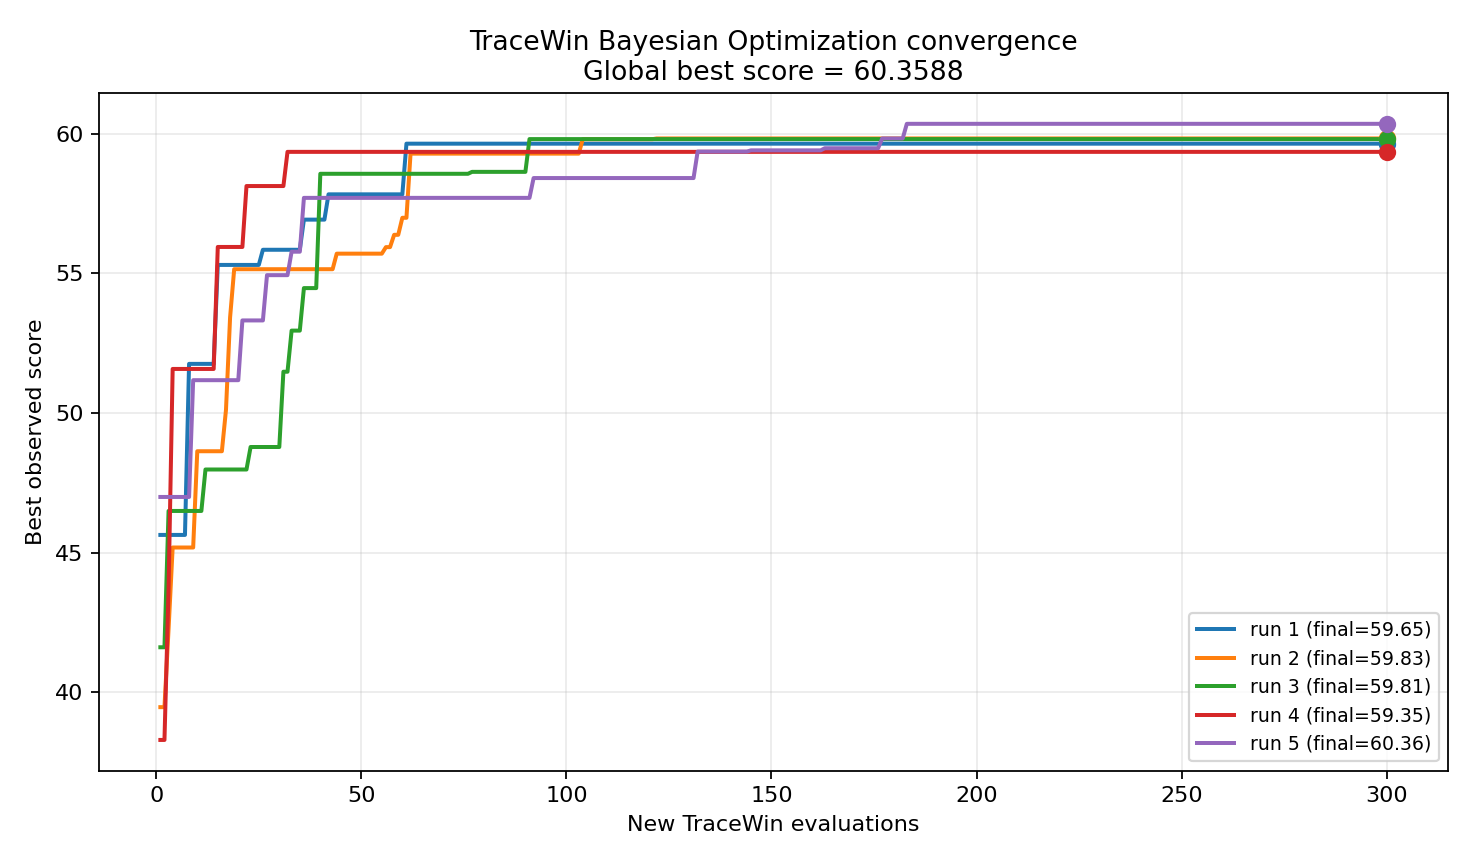

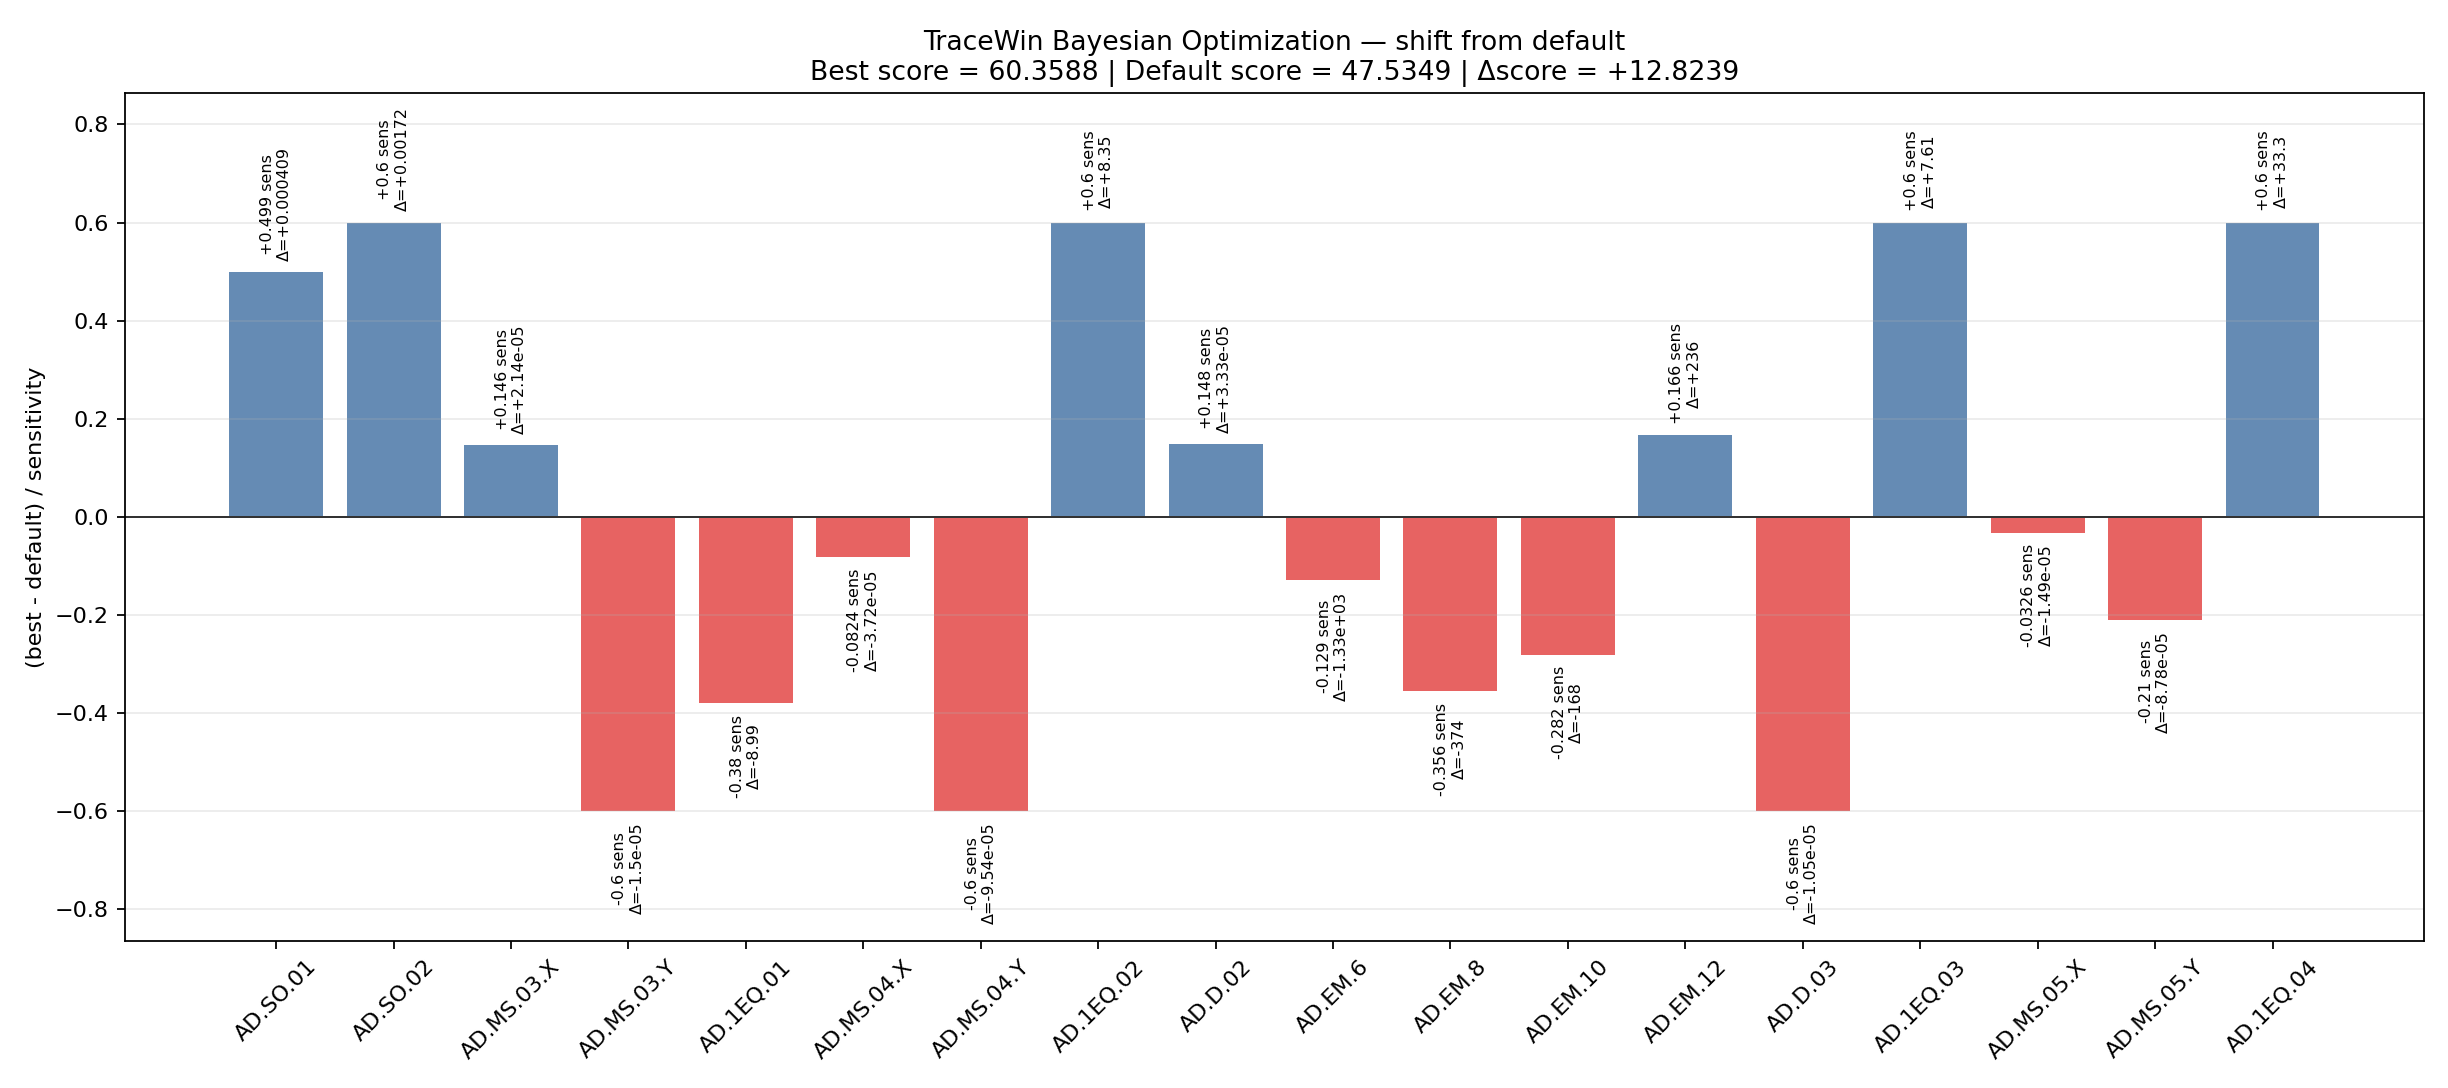

In [4]:
best_result = report.get('best_result')
default_result = report.get('default_result')

with tempfile.TemporaryDirectory() as tmp:
    tmp_json = Path(tmp) / 'results.json'
    convergence_path = save_convergence_plot(report, tmp_json)
    convergence_bytes = convergence_path.read_bytes() if convergence_path is not None else None
    delta_bytes = None
    if best_result is not None:
        delta_path = save_delta_plot(best_result, tmp_json, default_result=default_result)
        delta_bytes = delta_path.read_bytes()

if convergence_bytes is not None:
    display(Image(data=convergence_bytes))
else:
    print('No completed evaluations to plot yet.')

if delta_bytes is not None:
    display(Image(data=delta_bytes))
else:
    print('No best_result recorded yet -- delta plot skipped.')

## 3. Wall-clock cost

Every evaluation in the `"bayesian"` phase carries a `timestamp`; warm-start points do not, since they
are reused rows from an existing offline dataset rather than fresh TraceWin calls, so they contribute
zero additional wall-clock time. This section answers a different question than section 2: not "how
many TraceWin evaluations were needed", but **how long did that actually take on the clock** -- the
number that matters when deciding whether Bayesian Optimization is a practical alternative to training
an RL policy for repeated, fast inference.

Per-run duration is the span between its first and last evaluation timestamp. If runs were executed
sequentially (one after another, the default for `scripts/bayesian_opt.py`), the sum of per-run
durations should match the overall report span (`updated_at - created_at`); a large gap between the two
is a sign runs overlapped (executed concurrently) or the process was paused/resumed between runs.

In [5]:
def _parse(ts):
    return datetime.fromisoformat(ts)

run_rows = []
all_timestamps = []
total_seconds = 0.0
total_evaluations = 0
total_failed = 0
per_run_stats = []

for run in runs:
    evaluations = [e for e in run['evaluations'] if e.get('timestamp')]
    if not evaluations:
        continue
    timestamps = [_parse(e['timestamp']) for e in evaluations]
    all_timestamps.extend(timestamps)
    start, end = min(timestamps), max(timestamps)
    duration = (end - start).total_seconds()
    n_failed = sum(1 for e in evaluations if not e.get('success', True))
    avg_per_eval = duration / max(1, len(evaluations) - 1) if len(evaluations) > 1 else float('nan')
    total_seconds += duration
    total_evaluations += len(evaluations)
    total_failed += n_failed
    per_run_stats.append({
        'run_index': run['run_index'],
        'start': start, 'end': end, 'duration': duration,
        'n_evaluations': len(evaluations), 'n_failed': n_failed,
        'best_score': run.get('best_score'),
    })
    run_rows.append([
        run['run_index'] + 1,
        f"{len(evaluations):,}",
        n_failed,
        start.strftime('%Y-%m-%d %H:%M:%S'),
        fmt_duration(duration),
        fmt(avg_per_eval),
        fmt(run.get('best_score')),
    ])

display(Markdown(table(
    ['Run', 'Evaluations', 'Failed', 'Started', 'Duration', 'Avg s/eval', 'Best score'],
    run_rows,
)))

overall_span = (max(all_timestamps) - min(all_timestamps)).total_seconds() if all_timestamps else None
avg_per_eval_overall = total_seconds / max(1, total_evaluations - len(per_run_stats))
warm_start_size = len(report.get('warm_start', []))

summary_rows = [
    ['Total new TraceWin evaluations', f'{total_evaluations:,}'],
    ['Failed evaluations', f'{total_failed:,} ({100 * total_failed / max(1, total_evaluations):.2f}%)'],
    ['Warm-start points reused (zero extra cost)', f'{warm_start_size:,}'],
    ['Sum of per-run durations', fmt_duration(total_seconds)],
    ['Overall span (first to last timestamp)', fmt_duration(overall_span)],
    ['Report span (updated_at - created_at)', fmt_duration(
        (_parse(report['updated_at']) - _parse(report['created_at'])).total_seconds()
        if report.get('updated_at') and report.get('created_at') else None
    )],
    ['Average time per TraceWin evaluation', f'{avg_per_eval_overall:.1f}s'],
]
display(Markdown(table(['Metric', 'Value'], summary_rows)))

if best_result is not None and best_result.get('timestamp'):
    best_ts = _parse(best_result['timestamp'])
    owning_run = next(
        (r for r in per_run_stats if r['run_index'] == best_result.get('run_index')), None
    )
    if owning_run is not None:
        time_to_best_in_run = (best_ts - owning_run['start']).total_seconds()
        runs_before = sum(
            r['duration'] for r in per_run_stats if r['run_index'] < owning_run['run_index']
        )
        time_to_best_overall = runs_before + time_to_best_in_run
        display(Markdown(
            f"**Time to reach the global best score ({fmt(best_result['score'])})**: "
            f"{fmt_duration(time_to_best_in_run)} into run {owning_run['run_index'] + 1} "
            f"(evaluation {best_result.get('call_index', '?')} of that run's "
            f"{owning_run['n_evaluations']}), {fmt_duration(time_to_best_overall)} of total wall-clock "
            f"time into the whole {len(per_run_stats)}-run experiment."
        ))

| Run | Evaluations | Failed | Started | Duration | Avg s/eval | Best score |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 300 | 1 | 2026-08-05 15:06:48 | 2h 14m 41s | 27.0272 | 59.6474 |
| 2 | 300 | 1 | 2026-08-05 17:22:20 | 2h 4m 19s | 24.949 | 59.8347 |
| 3 | 300 | 0 | 2026-08-05 19:27:25 | 1h 58m 58s | 23.8741 | 59.8115 |
| 4 | 300 | 0 | 2026-08-05 21:27:08 | 1h 52m 47s | 22.635 | 59.3543 |
| 5 | 300 | 6 | 2026-08-05 23:20:39 | 1h 57m 13s | 23.5241 | 60.3588 |

| Metric | Value |
| --- | --- |
| Total new TraceWin evaluations | 1,500 |
| Failed evaluations | 8 (0.53%) |
| Warm-start points reused (zero extra cost) | 46 |
| Sum of per-run durations | 10h 8m 0s |
| Overall span (first to last timestamp) | 10h 11m 4s |
| Report span (updated_at - created_at) | 10h 11m 58s |
| Average time per TraceWin evaluation | 24.4s |

**Time to reach the global best score (60.3588)**: 55m 35s into run 5 (evaluation 182 of that run's 300), 9h 6m 22s of total wall-clock time into the whole 5-run experiment.

## 4. Convergence against wall-clock time

The same best-so-far curves as section 2, but on a time axis (minutes elapsed since each run's first
evaluation) instead of an evaluation count -- evaluations do not all cost the same amount of time
(TraceWin runtime varies with the beam state being simulated, retries on transient failures, cluster
load), so two runs at "evaluation 100" are not necessarily at the same point in wall-clock cost. This
plot is not part of `scripts/bayesian_opt.py`'s output; it is built here directly from each
evaluation's `timestamp`.

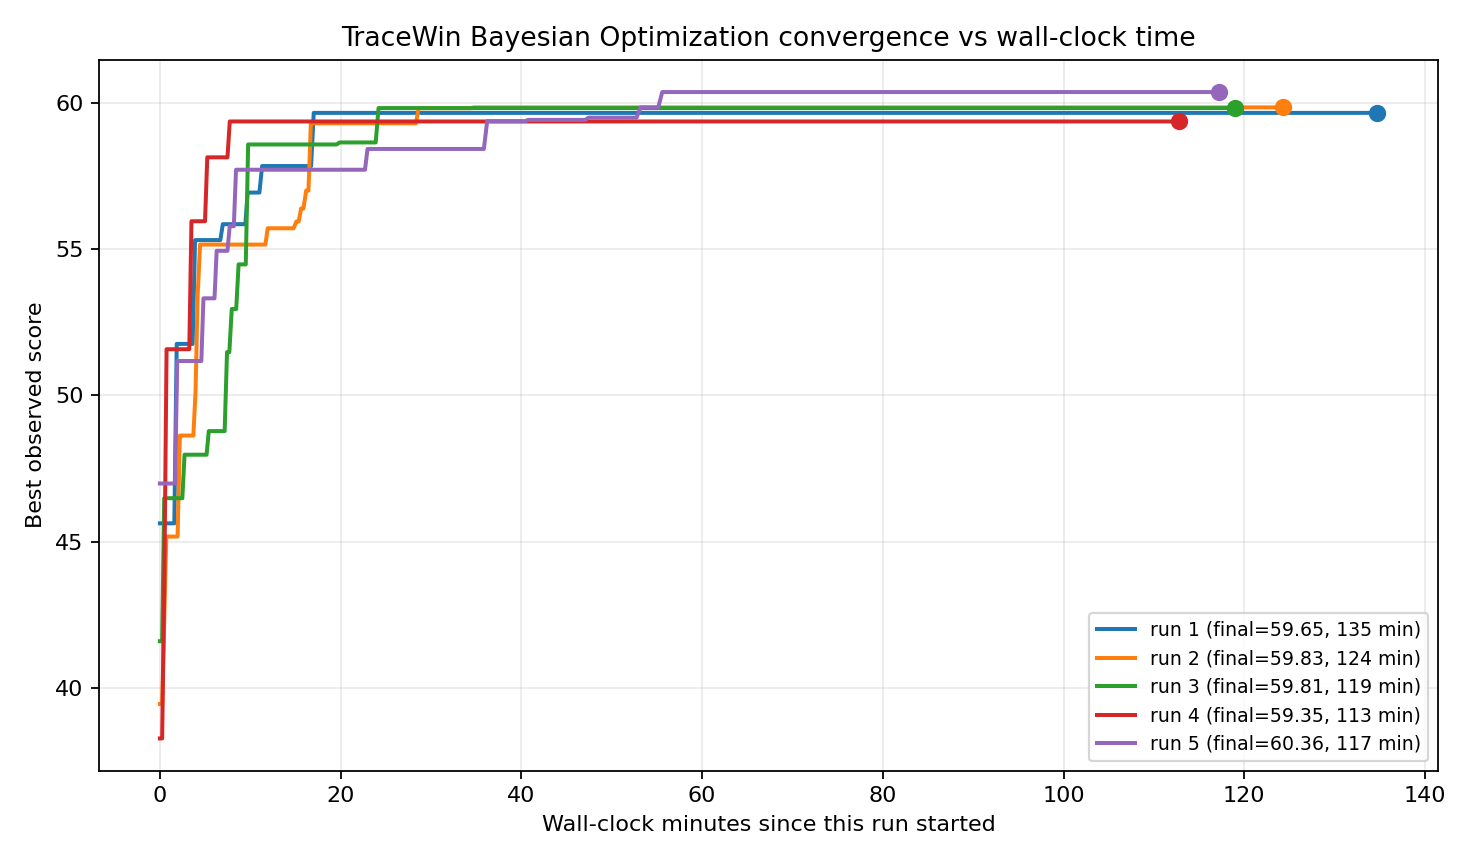

In [6]:
from beam_optimization.config.paths import configure_matplotlib_cache

configure_matplotlib_cache()
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(9.2, 5.4))
for run in runs:
    evaluations = [e for e in run['evaluations'] if e.get('timestamp') and e.get('success', True) is not None]
    if not evaluations:
        continue
    timestamps = [_parse(e['timestamp']) for e in evaluations]
    scores = np.asarray([e['score'] for e in evaluations], dtype=float)
    start = min(timestamps)
    minutes = np.asarray([(ts - start).total_seconds() / 60.0 for ts in timestamps])
    order = np.argsort(minutes)
    best_so_far = np.maximum.accumulate(scores[order])
    duration_min = minutes[order][-1]
    line, = axis.plot(
        minutes[order], best_so_far, linewidth=1.8,
        label=f"run {run['run_index'] + 1} (final={best_so_far[-1]:.4g}, {duration_min:.0f} min)",
    )
    axis.scatter(minutes[order][-1], best_so_far[-1], s=46, color=line.get_color(), zorder=4)

axis.set_xlabel('Wall-clock minutes since this run started')
axis.set_ylabel('Best observed score')
axis.set_title('TraceWin Bayesian Optimization convergence vs wall-clock time')
axis.grid(alpha=0.25)
axis.legend(fontsize=8.5)
figure.tight_layout()

import io
_buffer = io.BytesIO()
figure.savefig(_buffer, format='png', dpi=160)
plt.close(figure)
display(Image(data=_buffer.getvalue()))

## 5. Where this fits in the pipeline

- Sections 1-2 mirror exactly what `python -m beam_optimization bayesian_opt` writes to
  `results/bayesian_opt/<name>/` -- same `save_convergence_plot()`/`save_delta_plot()` calls, just
  rendered inline instead of saved as standalone PNGs.
- Section 3-4 (wall-clock timing) are specific to this notebook: they read the `timestamp` already
  recorded on every evaluation, so they need no re-simulation and stay accurate for any completed or
  in-progress report.
- The `tracewin_threads`/`timeout`/`retries` settings in section 1 directly set the wall-clock budget in
  section 3 -- comparing timing numbers across two experiment folders is only meaningful if those
  settings match; otherwise the difference may reflect the environment, not the optimizer.
- See `scripts/bayesian_opt.py` for how a report gets produced (`commands/bayesian_opt.sh` for a warm
  start against a TraceWin dataset, `commands/bayesian_opt_cold_start.sh` for a cold start).